<a href="https://www.kaggle.com/code/nikita2901699/practical-nn?scriptVersionId=294177046" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import torch  
from torchvision import datasets, transforms 

In [2]:
data_dir = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_0"

In [3]:
dataset0 = datasets.ImageFolder(data_dir)

In [4]:
len(dataset0)

3527

In [5]:
img, label = dataset0[3526]

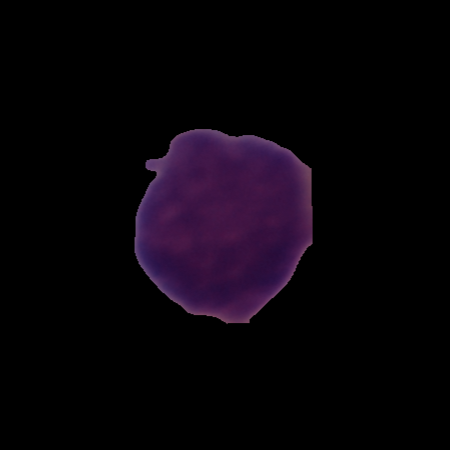

In [6]:
img

In [7]:
dataset0.classes

['all', 'hem']

In [8]:
data_dir1 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_1"
dataset1 = datasets.ImageFolder(data_dir1)

data_dir2 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_2"
dataset2 = datasets.ImageFolder(data_dir2)

In [9]:
dataset0.classes
dataset1.classes
dataset2.classes

['all', 'hem']

In [10]:
dataset_all = torch.utils.data.ConcatDataset([dataset0, dataset1, dataset2])

In [11]:
len(dataset_all)

10661

In [12]:
data_train, data_test = torch.utils.data.random_split(dataset_all,[0.8, 0.2])

In [13]:
len(data_train)


8529

In [14]:
len(data_test)


2132

In [15]:
img, label = data_train[5000]

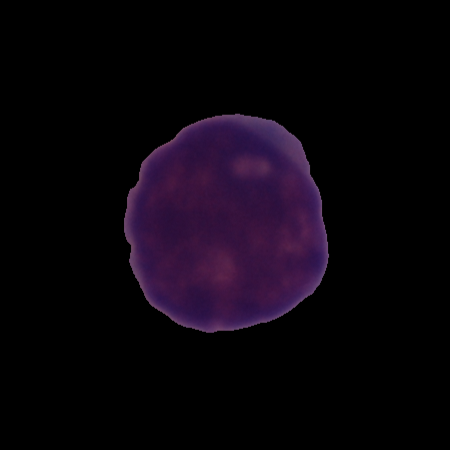

In [16]:
img

In [19]:
train_transform = transforms.Compose(
    [transforms.Resize([200, 200]),
    transforms.CenterCrop(180),
    transforms.RandomRotation(180),
    transforms.ToTensor()
    ]
)

In [20]:
train_transform(img).shape

torch.Size([3, 180, 180])

In [21]:
test_transform = transforms.Compose(
    [transforms.Resize([200, 200]),
    transforms.CenterCrop(180),
    transforms.ToTensor()
    ]
)

In [22]:
test_transform(img).shape

torch.Size([3, 180, 180])

In [23]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, y = self.dataset[idx]

        new_img = self.transformer(img)
        
        return new_img, y

In [24]:
train_data = TransformDataset(data_train,train_transform)

In [25]:
test_data = TransformDataset(data_test,test_transform)

In [26]:
len(test_data)

2132

In [27]:
test_data[2100]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 0)

In [28]:
train_loader = DataLoader(train_data, batch_size=256)

In [29]:
test_loader = DataLoader(test_data, batch_size=256)


In [ ]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape) 


In [ ]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset0.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

In [ ]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

  
batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [ ]:
3*60*60

In [48]:
# from torch import nn

# model = nn.Sequential(
#     nn.Flatten(),
#     nn.Linear(10800, 64),
#     nn.ReLU(),
#     nn.Linear(64, 32),
#     nn.ReLU(),
#     nn.Linear(32, 16),
#     nn.ReLU(),
#     nn.Linear(16, 2)
# )

# device = "cuda"
# model = model.to(device)

from torch import nn

model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding='same'),# розмір буде 8,180,180
    nn.ReLU(),
    nn.MaxPool2d(2,2), #8, 90 , 90
    nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding='same'),#16, 90, 90
    nn.ReLU(), # 16, 90, 90
    nn.MaxPool2d(2, 2), # 16, 45, 45
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding='same'), #32, 45, 45
    nn.ReLU(), #32, 45, 45
    nn.MaxPool2d(2, 2), # 32, 22, 22

    nn.Flatten(), # 32*22*22 - 15488
    nn.Linear(15488, 16),
    nn.ReLU(),
    nn.Linear(16, 2)
)

device = 'cuda'
model = model.to(device)

In [38]:
32*22*22

15488

In [41]:
for imgs, labels in train_loader:
    break

In [42]:
imgs.shape

torch.Size([256, 3, 180, 180])

In [43]:
res = model(imgs)
res.shape

torch.Size([256, 2])

In [49]:
# функция ошибки для задачи многоклассовой классификации
loss_fn = nn.CrossEntropyLoss()

# оптимизатор Adam для обучения нейронной сети
optimizer = torch.optim.Adam(
    model.parameters(),   # параметры модели
    lr=0.001
)

# список для сохранения значений loss во время обучения
loss_list = []
loss_test_list = []

# цикл обучения по эпохам
for i in range(3):

    # перебор батчей из обучающего даталоадера
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        loss.backward()               # вычисление градиентов
        optimizer.step()              # обновление весов модели
        optimizer.zero_grad()         # очистка градиентов

        loss_list.append(loss.cpu().item())  # сохранение значения loss

    #test data
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        

        loss_test_list.append(loss.cpu().item())  # сохранение значения loss


loss: 0.6592129468917847
loss: 0.6426950693130493
loss: 0.6108571290969849
loss: 0.6681473255157471
loss: 0.6288834810256958
loss: 0.6480798721313477
loss: 0.6167089343070984
loss: 0.6287294626235962
loss: 0.6302998661994934
loss: 0.6186736822128296
loss: 0.6041315793991089
loss: 0.6565698981285095
loss: 0.5705740451812744
loss: 0.5734168291091919
loss: 0.5869520306587219
loss: 0.5152507424354553
loss: 0.5506793260574341
loss: 0.5683618783950806
loss: 0.5094023942947388
loss: 0.5087617635726929
loss: 0.5338760614395142
loss: 0.5265637636184692
loss: 0.4704020321369171
loss: 0.44963884353637695
loss: 0.4807644784450531
loss: 0.4960678517818451
loss: 0.5127443671226501
loss: 0.49906960129737854
loss: 0.5472355484962463
loss: 0.5037404298782349
loss: 0.45706719160079956
loss: 0.44334208965301514
loss: 0.495098352432251
loss: 0.39776837825775146
loss: 0.42144137620925903
loss: 0.5048199892044067
loss: 0.43549928069114685
loss: 0.5630166530609131
loss: 0.5187541246414185
loss: 0.53357207775

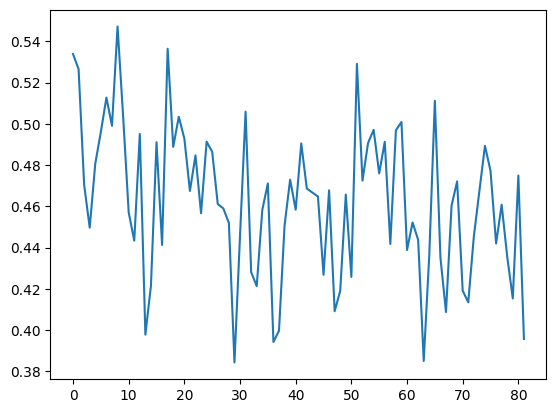

In [50]:
import matplotlib.pyplot as plt

new_list = loss_list[20 :]

plt.plot(new_list)



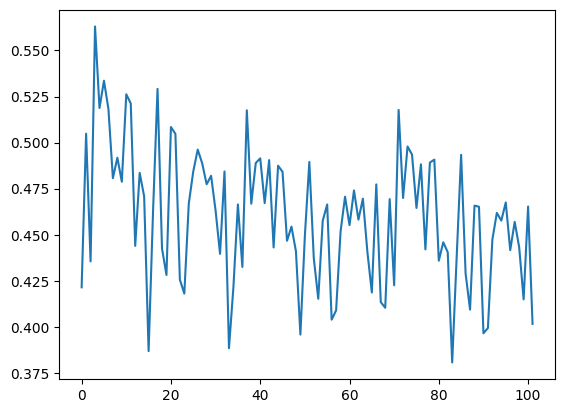

In [51]:
plt.plot(loss_test_list)

In [53]:
imgs.shape

torch.Size([81, 3, 180, 180])

In [ ]:
img, label = train_data[100]
img = img.unsqueeze(0)
img.shape

In [ ]:
img = img.to(device)
prediction = model(img)
print(label)
print(nn.Softmax()(prediction))

In [57]:
result = model(imgs)

In [60]:
res1 = result.argmax(dim=1)

In [59]:
labels

tensor([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
        0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1,
        0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 1, 0, 0, 1, 1, 1, 0, 1], device='cuda:0')

In [64]:
res2 = res1 == labels

In [66]:
res2.sum()

tensor(67, device='cuda:0')

In [67]:
67/81

0.8271604938271605

In [79]:
count = 0



for imgs, labels in train_loader:
    imgs = imgs.to(device)
    labels = labels.to(device)
    res = model(imgs)
    res = res.argmax(dim=1)
    res2 = res == labels
    summa = res2.sum()
    count += summa.cpu().item()

print(count) 

6829


In [94]:
len(train_data) 

8529

In [95]:
6829/8529

0.8006800328291711